$f(x)=x^2-4x+5 $

\begin{aligned}
f(x)&=x^2-4x+5\\
&=(x^2-4x+4)+1\\
&=(x-2)^2+1
\end{aligned}

$x=2, \quad \text{min}=f(2)=1$

$f'(x)=2x-4$

\begin{align}
2x-4&=0\\
x&=2
\end{align}

,eta,final_x,final_f,distance_from_minimizer
0,0.01,4.181937,5.760850,2.181937e+00
1,0.10,2.004952,1.000025,4.951760e-03
2,0.80,2.000001,1.000000,8.842957e-07
3,1.10,951.505255,901561.229651,9.495053e+02


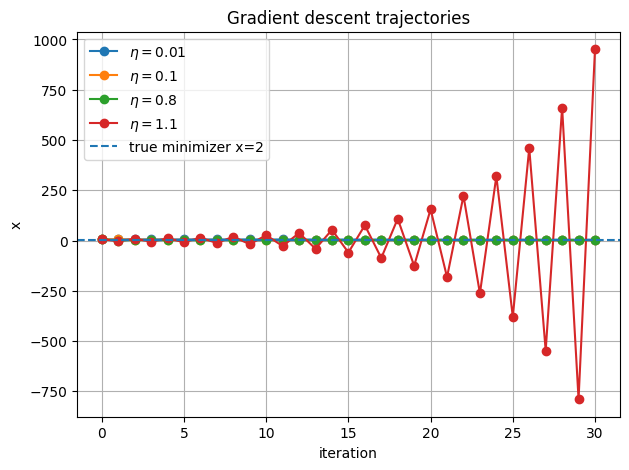

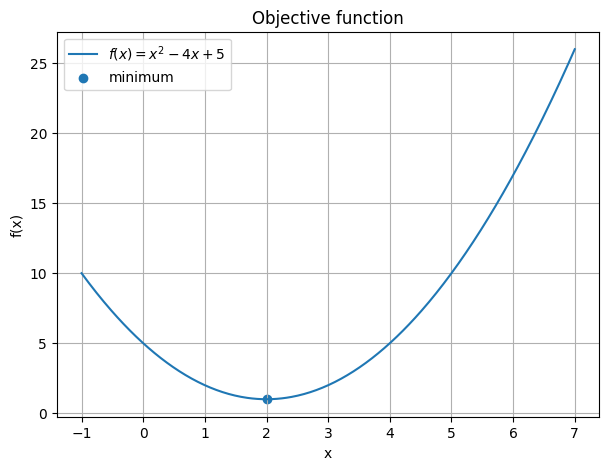

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def f(x):
    return x**2 - 4*x + 5

def grad_f(x):
    return 2*x - 4

def gradient_descent(x0, eta, n_iter=30):
    xs = [x0]
    for _ in range(n_iter):
        x_new = xs[-1] - eta * grad_f(xs[-1])
        xs.append(x_new)
    return np.array(xs)

x0 = 6.0
etas = [0.01, 0.1, 0.8, 1.1]
n_iter = 30

summary = []
histories = {}

for eta in etas:
    xs = gradient_descent(x0, eta, n_iter)
    histories[eta] = xs
    summary.append({
        "eta": eta,
        "final_x": xs[-1],
        "final_f": f(xs[-1]),
        "distance_from_minimizer": abs(xs[-1] - 2)
    })

display(pd.DataFrame(summary))

plt.figure(figsize=(7, 5))
for eta, xs in histories.items():
    plt.plot(range(len(xs)), xs, marker="o", label=fr"$\eta={eta}$")
plt.axhline(2, linestyle="--", label="true minimizer x=2")
plt.xlabel("iteration")
plt.ylabel("x")
plt.title("Gradient descent trajectories")
plt.grid(True)
plt.legend()
plt.show()

x_plot = np.linspace(-1, 7, 400)
plt.figure(figsize=(7, 5))
plt.plot(x_plot, f(x_plot), label=r"$f(x)=x^2-4x+5$")
plt.scatter([2], [f(2)], label="minimum")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Objective function")
plt.grid(True)
plt.legend()
plt.show()

$x_{\mathrm{new}}=x-\eta f'(x)$

この関数では最小点が $x=2$．

$\eta=0.01$ では収束が遅く，$\eta=0.1$ では安定して近づく．$\eta=0.8$ では振動しながら近づくが，$\eta=1.1$ では振動が大きくなり発散しやすい．